# MNIST Pipeline: LeNet-5 Feature Extraction → 10 Logistic Regressors → Softmax

**Pipeline Overview:**
1. Load MNIST dataset
2. Train a LeNet-5 CNN on MNIST
3. Remove the classification head → extract feature vectors
4. Train 10 One-vs-Rest Logistic Regression models (one per digit 0–9)
5. Stack outputs into a 1×10 probability vector → apply Softmax
6. Evaluate with regularization analysis, bias–variance diagnostics, and learning curves

## Cell 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve
import warnings, os

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


logistic regression function

In [2]:
class LogisticRegression:
    def __init__(self, lr=0.01, max_iter=2000, C=1.0,
                 tol=1e-6, fit_intercept=True,
                 penalty="l2", random_state=None,
                 solver=None):

        self.lr = lr
        self.max_iter = max_iter
        self.C = C
        self.tol = tol
        self.fit_intercept = fit_intercept
        self.penalty = penalty

    @staticmethod
    def _sigmoid(z):
        pos = z >= 0
        result = np.empty_like(z, dtype=float)

        result[pos] = 1.0 / (1.0 + np.exp(-z[pos]))

        exp_z = np.exp(z[~pos])
        result[~pos] = exp_z / (1.0 + exp_z)

        return result

    def _add_intercept(self, X):
        if self.fit_intercept:
            return np.hstack([np.ones((X.shape[0], 1)), X])
        return X

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        X = self._add_intercept(X)

        n_samples, n_features = X.shape

        self.weights_ = np.zeros(n_features)

        reg = 1.0 / self.C
        prev_loss = np.inf

        self.loss_history_ = []

        for _ in range(self.max_iter):

            z = X @ self.weights_
            h = self._sigmoid(z)

            eps = 1e-15

            # Cross entropy loss
            loss = (-1 / n_samples) * (
                y @ np.log(h + eps)
                + (1 - y) @ np.log(1 - h + eps)
            )

            # L2 regularization
            if self.penalty == "l2":
                loss += 0.5 * reg * np.dot(self.weights_, self.weights_)
                grad = (
                    (1 / n_samples) * (X.T @ (h - y))
                    + reg * self.weights_
                )

            # L1 regularization
            elif self.penalty == "l1":
                loss += reg * np.sum(np.abs(self.weights_))
                grad = (
                    (1 / n_samples) * (X.T @ (h - y))
                    + reg * np.sign(self.weights_)
                )

            else:
                grad = (1 / n_samples) * (X.T @ (h - y))

            self.loss_history_.append(loss)

            self.weights_ -= self.lr * grad

            if abs(prev_loss - loss) < self.tol:
                break

            prev_loss = loss

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        X = self._add_intercept(X)

        logits = X @ self.weights_

        probs_1 = self._sigmoid(logits)
        probs_0 = 1 - probs_1

        return np.column_stack([probs_0, probs_1])

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= 0.5).astype(int)

In [3]:
transform = transforms.Compose([
    transforms.Pad(2),                          # 28×28 → 32×32 (LeNet-5 input)
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST global mean / std
])

full_train = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Combine train (60 000) + test (10 000) = 70 000, then split 70/15/15
all_indices = np.arange(len(full_train) + len(test_set))  # 70 000
np.random.seed(42)
np.random.shuffle(all_indices)

n_total = len(all_indices)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
# n_test  = remainder

train_idx = all_indices[:n_train]
val_idx   = all_indices[n_train:n_train + n_val]
test_idx  = all_indices[n_train + n_val:]

# We'll work from full_train + test_set via ConcatDataset
full_dataset = torch.utils.data.ConcatDataset([full_train, test_set])

train_subset = Subset(full_dataset, train_idx)
val_subset   = Subset(full_dataset, val_idx)
test_subset  = Subset(full_dataset, test_idx)

print(f"Split sizes  →  Train: {len(train_subset)}  |  Val: {len(val_subset)}  |  Test: {len(test_subset)}")

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_subset,  batch_size=256, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 356kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.31MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]

Split sizes  →  Train: 49000  |  Val: 10500  |  Test: 10500


## Cell 3 — Define LeNet-5 Architecture

In [4]:
class LeNet5(nn.Module):
    """
    Classic LeNet-5 (LeCun et al., 1998) adapted for MNIST.
    Input : 1 × 32 × 32
    Output: 10-class logits (used only during CNN pretraining)
    """
    def __init__(self):
        super().__init__()
        # ── Convolutional backbone ──
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),     # → 6  × 28 × 28
            nn.ReLU(),
            nn.AvgPool2d(2, 2),                 # → 6  × 14 × 14
            nn.Conv2d(6, 16, kernel_size=5),    # → 16 × 10 × 10
            nn.ReLU(),
            nn.AvgPool2d(2, 2),                 # → 16 ×  5 ×  5
        )
        # ── Fully-connected feature layers ──
        self.feature_fc = nn.Sequential(
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
        )
        # ── Classification head (will be DISABLED later) ──
        self.classifier = nn.Linear(84, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)              # flatten
        x = self.feature_fc(x)
        x = self.classifier(x)
        return x

    def extract_features(self, x):
        """Forward pass through the backbone ONLY → returns 84-d feature vector."""
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.feature_fc(x)
        return x                                # shape: (batch, 84)


model = LeNet5().to(DEVICE)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (feature_fc): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU()
  )
  (classifier): Linear(in_features=84, out_features=10, bias=True)
)

Total parameters: 61,706


## Cell 4 — Pretrain LeNet-5 on MNIST

In [5]:
EPOCHS   = 10
LR       = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Training ──
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += images.size(0)
    train_losses.append(running_loss / total)
    train_accs.append(correct / total)

    # ── Validation ──
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total   += images.size(0)
    val_losses.append(running_loss / total)
    val_accs.append(correct / total)

    print(f"Epoch {epoch:>2}/{EPOCHS}  │  "
          f"Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.4f}  │  "
          f"Val   Loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]:.4f}")

print("\n✓ LeNet-5 pretraining complete.")

Epoch  1/10  │  Train Loss: 0.3887  Acc: 0.8858  │  Val   Loss: 0.1559  Acc: 0.9525
Epoch  2/10  │  Train Loss: 0.1138  Acc: 0.9647  │  Val   Loss: 0.0938  Acc: 0.9723
Epoch  3/10  │  Train Loss: 0.0797  Acc: 0.9751  │  Val   Loss: 0.0724  Acc: 0.9781
Epoch  4/10  │  Train Loss: 0.0615  Acc: 0.9810  │  Val   Loss: 0.0629  Acc: 0.9807
Epoch  5/10  │  Train Loss: 0.0532  Acc: 0.9833  │  Val   Loss: 0.0650  Acc: 0.9808
Epoch  6/10  │  Train Loss: 0.0442  Acc: 0.9861  │  Val   Loss: 0.0596  Acc: 0.9816
Epoch  7/10  │  Train Loss: 0.0372  Acc: 0.9878  │  Val   Loss: 0.0465  Acc: 0.9876
Epoch  8/10  │  Train Loss: 0.0333  Acc: 0.9888  │  Val   Loss: 0.0510  Acc: 0.9847
Epoch  9/10  │  Train Loss: 0.0305  Acc: 0.9902  │  Val   Loss: 0.0552  Acc: 0.9838
Epoch 10/10  │  Train Loss: 0.0265  Acc: 0.9909  │  Val   Loss: 0.0576  Acc: 0.9840

✓ LeNet-5 pretraining complete.


## Cell 5 — Plot CNN Training Curves

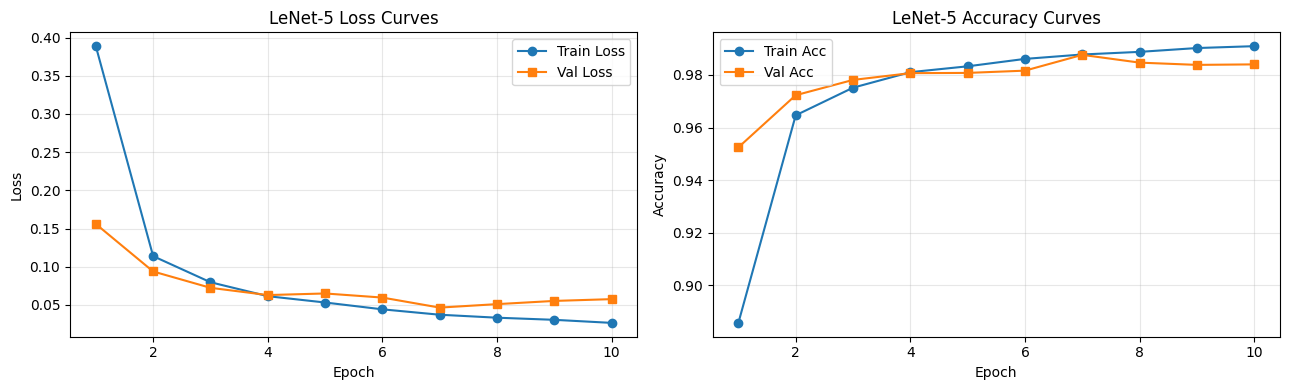

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, train_losses, "o-", label="Train Loss")
ax1.plot(epochs_range, val_losses,   "s-", label="Val Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("LeNet-5 Loss Curves")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_accs, "o-", label="Train Acc")
ax2.plot(epochs_range, val_accs,   "s-", label="Val Acc")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("LeNet-5 Accuracy Curves")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/lenet5_training_curves.png", dpi=150)
plt.show()



```
# This is formatted as code
```

## Cell 6 — Disable Classification Head & Extract Features

Freeze the entire network — we only need it as a feature extractor now.  
The classifier head is effectively **DISABLED**: we call `extract_features()` instead of `forward()`, so the final `Linear(84→10)` layer is never executed.

In [7]:
model.eval()
for param in model.parameters():
    param.requires_grad = False

def extract_all_features(loader):
    """Run every batch through LeNet-5 backbone and collect (features, labels)."""
    all_feats, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            feats  = model.extract_features(images)    # 84-d vector per image
            all_feats.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_feats), np.concatenate(all_labels)

X_train, y_train = extract_all_features(train_loader)
X_val,   y_val   = extract_all_features(val_loader)
X_test,  y_test  = extract_all_features(test_loader)

print(f"Feature shapes  →  Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
print(f"Feature vector dimensionality: {X_train.shape[1]}  (classifier head disabled)")

Feature shapes  →  Train: (49000, 84)  |  Val: (10500, 84)  |  Test: (10500, 84)
Feature vector dimensionality: 84  (classifier head disabled)


## Cell 7 — Train 10 One-vs-Rest Logistic Regression Models

Each model k ∈ {0, 1, …, 9} is a **binary** logistic regression:
- Positive class: digit == k
- Negative class: digit != k

After training, each model outputs P(digit == k | features).  
We stack these 10 probabilities and apply softmax.

In [10]:
N_CLASSES = 10
lr_models = {}

print("Training 10 binary Logistic Regression models (One-vs-Rest):\n")

for k in range(N_CLASSES):

    # Create binary labels
    y_bin_train = (y_train == k).astype(int)
    y_bin_val   = (y_val == k).astype(int)

    clf = LogisticRegression(
        penalty="l2",
        C=1.0,
        lr=0.01,
        max_iter=2000,
    )

    clf.fit(X_train, y_bin_train)

    acc_train = accuracy_score(y_bin_train, clf.predict(X_train))
    acc_val   = accuracy_score(y_bin_val, clf.predict(X_val))

    print(f"  Digit {k}  │  Train Acc: {acc_train:.4f}  │  Val Acc: {acc_val:.4f}")

    lr_models[k] = clf

print("\n✓ All 10 logistic regression models trained.")

Training 10 binary Logistic Regression models (One-vs-Rest):

  Digit 0  │  Train Acc: 0.9981  │  Val Acc: 0.9974
  Digit 1  │  Train Acc: 0.9970  │  Val Acc: 0.9970
  Digit 2  │  Train Acc: 0.9955  │  Val Acc: 0.9952
  Digit 3  │  Train Acc: 0.9940  │  Val Acc: 0.9930
  Digit 4  │  Train Acc: 0.9960  │  Val Acc: 0.9955
  Digit 5  │  Train Acc: 0.9950  │  Val Acc: 0.9927
  Digit 6  │  Train Acc: 0.9983  │  Val Acc: 0.9962
  Digit 7  │  Train Acc: 0.9944  │  Val Acc: 0.9938
  Digit 8  │  Train Acc: 0.9934  │  Val Acc: 0.9914
  Digit 9  │  Train Acc: 0.9930  │  Val Acc: 0.9910

✓ All 10 logistic regression models trained.


## Cell 8 — Build the 1×10 Probability Vector & Apply Softmax

In [11]:
def predict_pipeline(X, lr_models):
    """
    For each sample, collect the raw logistic-regression probability from
    each of the 10 binary models, stack into a (N, 10) matrix, then apply
    softmax row-wise to obtain a proper probability distribution.

    Returns:
        probs      : (N, 10) softmax probabilities
        predictions: (N,)    argmax class labels
    """
    raw_probs = np.zeros((X.shape[0], N_CLASSES))
    for k in range(N_CLASSES):
        # predict_proba returns [[P(neg), P(pos)]] — we take P(pos)
        raw_probs[:, k] = lr_models[k].predict_proba(X)[:, 1]

    # ── Softmax ──
    # Subtract max for numerical stability, then exponentiate & normalise
    exp_scores = np.exp(raw_probs - raw_probs.max(axis=1, keepdims=True))
    probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)

    predictions = probs.argmax(axis=1)
    return probs, predictions

# Run full pipeline on each split
_, y_pred_train = predict_pipeline(X_train, lr_models)
_, y_pred_val   = predict_pipeline(X_val,   lr_models)
probs_test, y_pred_test = predict_pipeline(X_test, lr_models)

print("═" * 60)
print("        FULL PIPELINE RESULTS  (LeNet-5 → 10×LR → Softmax)")
print("═" * 60)
print(f"  Train Accuracy : {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Val   Accuracy : {accuracy_score(y_val,   y_pred_val):.4f}")
print(f"  Test  Accuracy : {accuracy_score(y_test,  y_pred_test):.4f}")
print("═" * 60)

════════════════════════════════════════════════════════════
        FULL PIPELINE RESULTS  (LeNet-5 → 10×LR → Softmax)
════════════════════════════════════════════════════════════
  Train Accuracy : 0.9909
  Val   Accuracy : 0.9836
  Test  Accuracy : 0.9836
════════════════════════════════════════════════════════════


## Cell 9 — Detailed Test-Set Evaluation


Classification Report (Test Set):

              precision    recall  f1-score   support

           0     0.9863    0.9902    0.9882      1018
           1     0.9868    0.9836    0.9852      1216
           2     0.9780    0.9789    0.9784      1088
           3     0.9781    0.9837    0.9809      1045
           4     0.9873    0.9892    0.9882      1019
           5     0.9884    0.9801    0.9842       956
           6     0.9912    0.9874    0.9893      1031
           7     0.9825    0.9834    0.9829      1082
           8     0.9672    0.9895    0.9782      1044
           9     0.9918    0.9700    0.9808      1001

    accuracy                         0.9836     10500
   macro avg     0.9838    0.9836    0.9836     10500
weighted avg     0.9837    0.9836    0.9836     10500



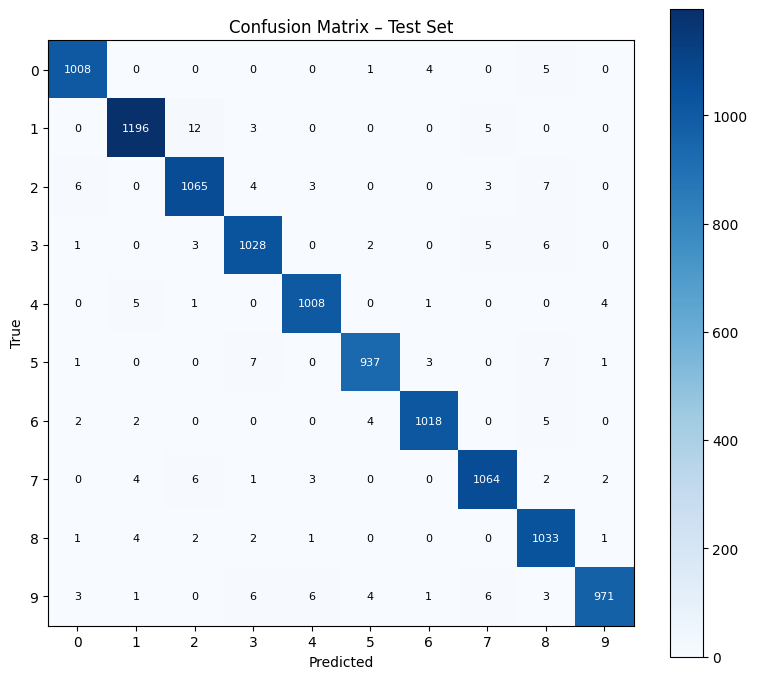

In [12]:
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_pred_test, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix – Test Set")
for i in range(10):
    for j in range(10):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8, color=color)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.show()

## Cell 10 — Sample Predictions Visualization

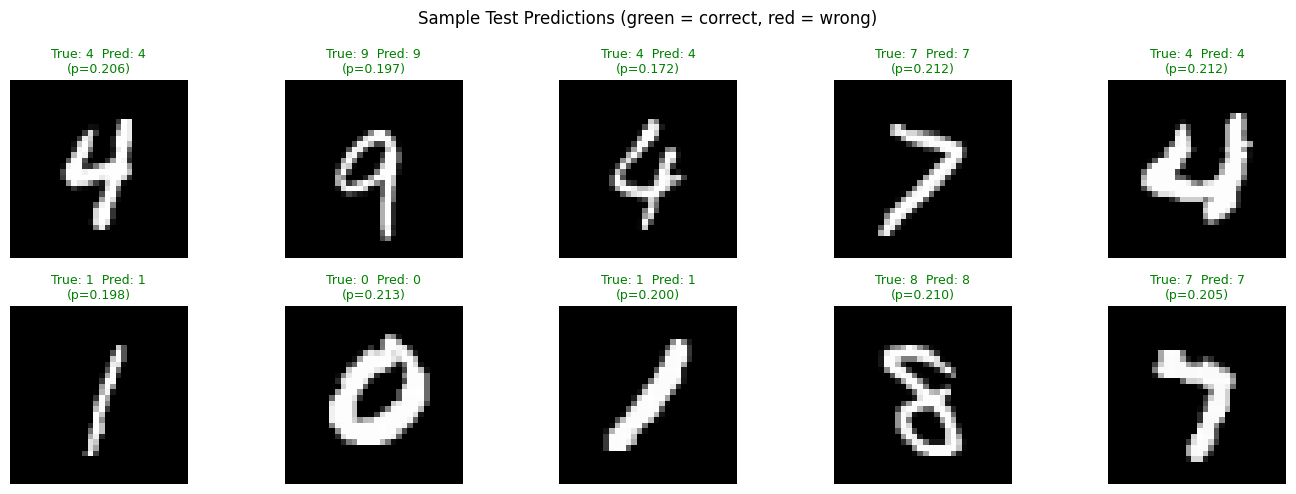

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
sample_indices = np.random.choice(len(X_test), 10, replace=False)

for ax, idx in zip(axes.ravel(), sample_indices):
    # Retrieve the original image from the test subset
    img, true_label = test_subset[idx]
    img_np = img.squeeze().numpy()

    pred_label = y_pred_test[idx]
    prob       = probs_test[idx, pred_label]
    color      = "green" if pred_label == true_label else "red"

    ax.imshow(img_np, cmap="gray")
    ax.set_title(f"True: {true_label}  Pred: {pred_label}\n(p={prob:.3f})", fontsize=9, color=color)
    ax.axis("off")

plt.suptitle("Sample Test Predictions (green = correct, red = wrong)", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/sample_predictions.png", dpi=150)
plt.show()

---
# Regularization & Diagnostics

## Cell 11 — L1 vs L2 Regularization Sweep

`C = 1 / λ` (smaller C → stronger regularization).  
We sweep C for both L1 and L2 and plot train vs validation accuracy.

Regularization sweep (this may take a few minutes)...

  L1  C=1.0       │  Train: 0.4645  Val: 0.4744

  L2  C=1.0       │  Train: 0.9909  Val: 0.9836



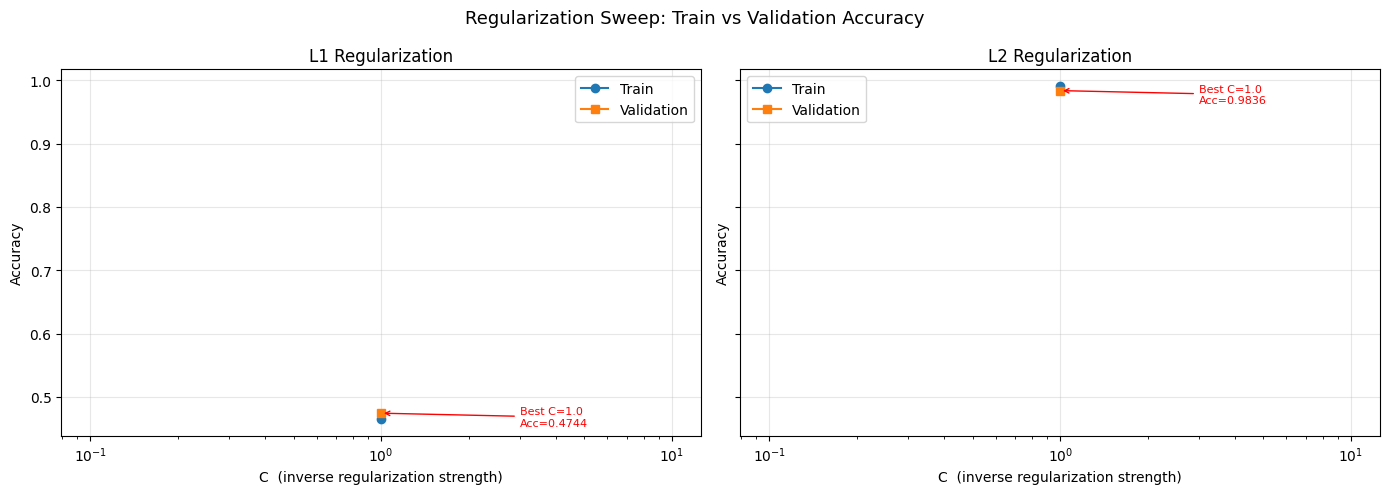

In [15]:
C_values = [1.0]

results = {
    "l1": {"train": [], "val": []},
    "l2": {"train": [], "val": []}
}

print("Regularization sweep (this may take a few minutes)...\n")

for penalty_type in ["l1", "l2"]:

    solver = None

    for C in C_values:

        temp_models = {}

        for k in range(N_CLASSES):

            clf = LogisticRegression(
                penalty=penalty_type,
                C=C,
                lr=0.01,
                max_iter=3000,
            )

            clf.fit(X_train, (y_train == k).astype(int))

            temp_models[k] = clf

        _, preds_tr = predict_pipeline(X_train, temp_models)
        _, preds_val = predict_pipeline(X_val, temp_models)

        acc_tr = accuracy_score(y_train, preds_tr)
        acc_val = accuracy_score(y_val, preds_val)

        results[penalty_type]["train"].append(acc_tr)
        results[penalty_type]["val"].append(acc_val)

        print(
            f"  {penalty_type.upper()}  C={C:<8}  │  "
            f"Train: {acc_tr:.4f}  Val: {acc_val:.4f}"
        )

    print()

# Plot
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 5), sharey=True
)

for ax, pen in zip([ax1, ax2], ["l1", "l2"]):

    ax.plot(C_values, results[pen]["train"], "o-", label="Train")
    ax.plot(C_values, results[pen]["val"], "s-", label="Validation")

    ax.set_xscale("log")
    ax.set_xlabel("C  (inverse regularization strength)")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{pen.upper()} Regularization")

    ax.legend()
    ax.grid(True, alpha=0.3)

    # Annotate best validation point
    best_idx = np.argmax(results[pen]["val"])
    best_c = C_values[best_idx]
    best_acc = results[pen]["val"][best_idx]

    ax.annotate(
        f"Best C={best_c}\nAcc={best_acc:.4f}",
        xy=(best_c, best_acc),
        fontsize=8,
        arrowprops=dict(arrowstyle="->", color="red"),
        xytext=(best_c * 3, best_acc - 0.02),
        color="red"
    )

plt.suptitle(
    "Regularization Sweep: Train vs Validation Accuracy",
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    "outputs/regularization_sweep.png",
    dpi=150
)

plt.show()

## Cell 12 — Bias–Variance / Overfitting–Underfitting Diagnosis

In [17]:
print("=" * 65)
print("   BIAS–VARIANCE & OVERFITTING / UNDERFITTING DIAGNOSIS")
print("=" * 65)

# Using the best L2 C from the sweep
best_l2_idx = np.argmax(results["l2"]["val"])
best_C = C_values[best_l2_idx]

# Recompute with different regularization strengths
diag_Cs = {
    "Very Strong Reg (C=0.001)": 0.001,
    "Strong Reg (C=0.01)": 0.01,
    "Moderate Reg (C=0.1)": 0.1,
    f"Optimal (C={best_C})": best_C,
    "Weak Reg (C=10)": 10.0,
    "No Reg (C=100)": 100.0
}

print(f"\n{'Setting':<30} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>8}  Diagnosis")
print("-" * 85)

for label, C in diag_Cs.items():

    temp_models = {}

    for k in range(N_CLASSES):

        clf = LogisticRegression(
            penalty="l2",
            C=C,
            lr=0.01,
            max_iter=3000,
        )

        clf.fit(X_train, (y_train == k).astype(int))

        temp_models[k] = clf

    _, p_tr = predict_pipeline(X_train, temp_models)
    _, p_val = predict_pipeline(X_val, temp_models)

    acc_tr = accuracy_score(y_train, p_tr)
    acc_val = accuracy_score(y_val, p_val)

    gap = acc_tr - acc_val

    # Diagnosis heuristic
    if acc_tr < 0.95 and acc_val < 0.95:
        diagnosis = "⚠ UNDERFITTING (high bias)"

    elif gap > 0.03:
        diagnosis = "⚠ OVERFITTING (high variance)"

    elif gap > 0.015:
        diagnosis = "~ Slight overfit"

    else:
        diagnosis = "✓ Good fit"

    print(
        f"  {label:<28} "
        f"{acc_tr:>10.4f} "
        f"{acc_val:>10.4f} "
        f"{gap:>+8.4f}  "
        f"{diagnosis}"
    )

print("-" * 85)

print("""
Interpretation Guide:
  • High bias (underfitting)
      → both train & validation accuracy are low
      → model is too simple or regularization too strong

  • High variance (overfitting)
      → train accuracy much higher than validation accuracy
      → model memorizes training data

  • Good fit
      → both accuracies are high
      → train/validation gap is small (< ~1.5%)
""")

   BIAS–VARIANCE & OVERFITTING / UNDERFITTING DIAGNOSIS

Setting                         Train Acc    Val Acc      Gap  Diagnosis
-------------------------------------------------------------------------------------
  Very Strong Reg (C=0.001)        0.0992     0.0974  +0.0018  ⚠ UNDERFITTING (high bias)
  Strong Reg (C=0.01)              0.9364     0.9325  +0.0039  ⚠ UNDERFITTING (high bias)
  Moderate Reg (C=0.1)             0.9890     0.9813  +0.0077  ✓ Good fit
  Optimal (C=1.0)                  0.9909     0.9836  +0.0073  ✓ Good fit
  Weak Reg (C=10)                  0.9927     0.9858  +0.0069  ✓ Good fit
  No Reg (C=100)                   0.9938     0.9865  +0.0074  ✓ Good fit
-------------------------------------------------------------------------------------

Interpretation Guide:
  • High bias (underfitting)
      → both train & validation accuracy are low
      → model is too simple or regularization too strong

  • High variance (overfitting)
      → train accuracy much hig

## Cell 13 — Learning Curves

We plot train & validation accuracy as a function of training-set size to visualise bias–variance behaviour.

Computing learning curves (this will take a few minutes)...



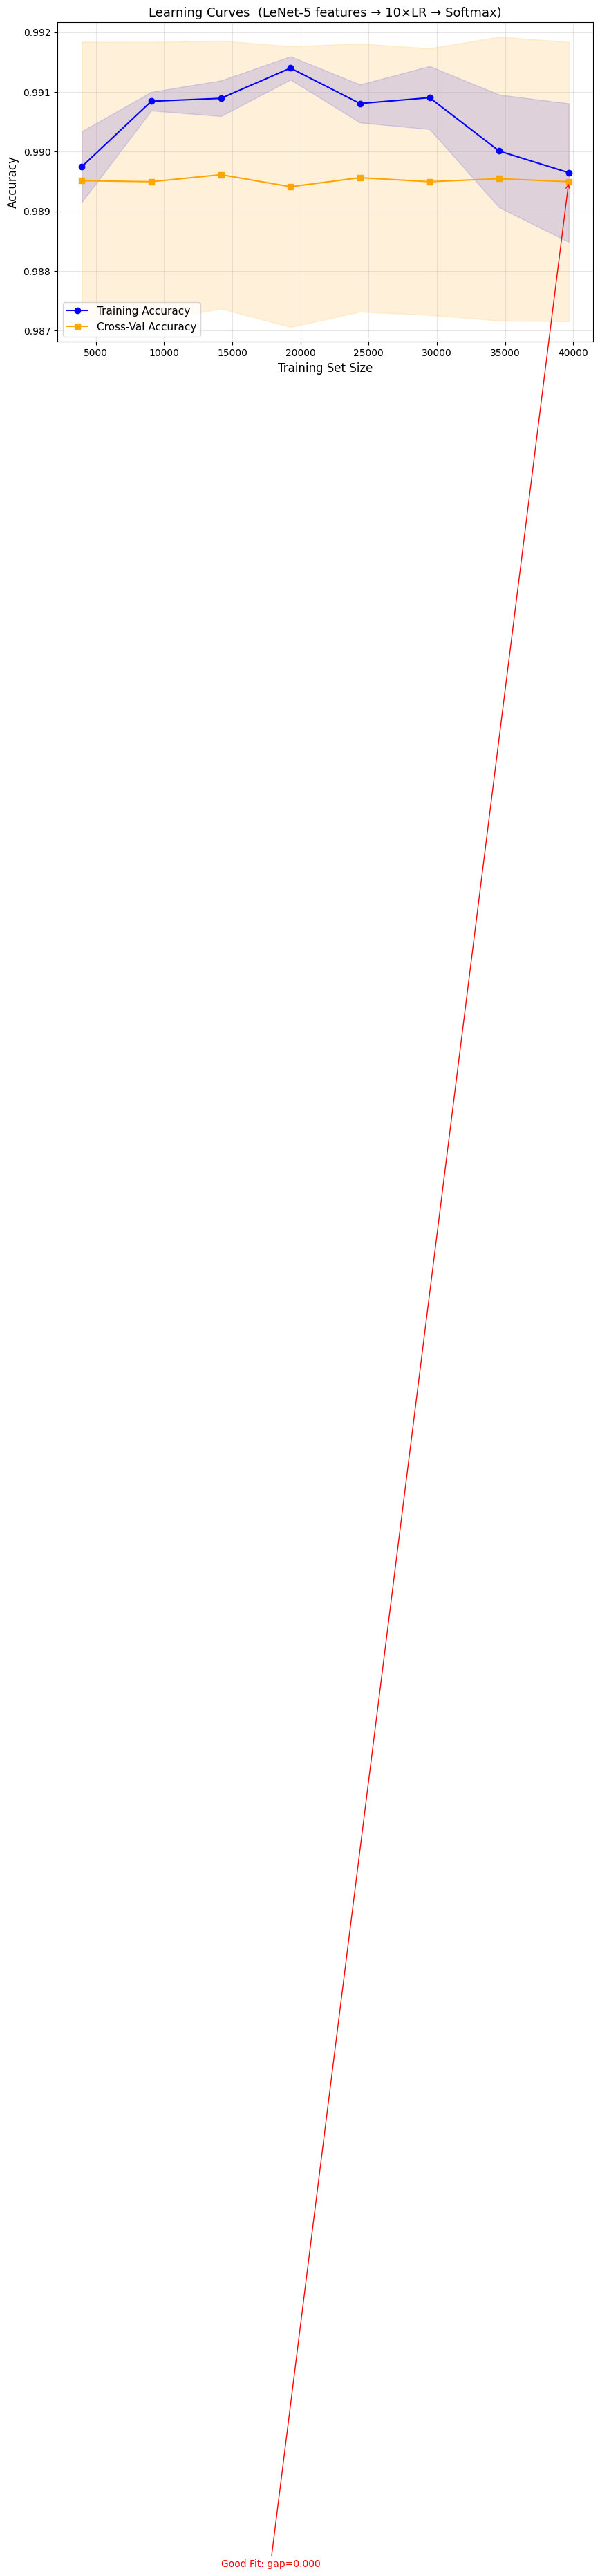

In [20]:
from sklearn.base import BaseEstimator, ClassifierMixin

class OvRSoftmaxClassifier(BaseEstimator, ClassifierMixin):
    """
    Wraps the 10 binary Logistic Regression + Softmax pipeline into a
    single sklearn-compatible estimator so we can use sklearn's
    learning_curve utility.
    """

    def __init__(self, C=1.0, penalty="l2"):
        self.C = C
        self.penalty = penalty

    def fit(self, X, y):

        self.models_ = {}

        solver = None

        for k in range(10):

            clf = LogisticRegression(
                penalty=self.penalty,
                C=self.C,
                lr=0.01,
                max_iter=3000,
            )

            clf.fit(X, (y == k).astype(int))

            self.models_[k] = clf

        return self

    def predict(self, X):

        raw = np.zeros((X.shape[0], 10))

        for k in range(10):
            raw[:, k] = self.models_[k].predict_proba(X)[:, 1]

        exp_s = np.exp(raw - raw.max(axis=1, keepdims=True))
        probs = exp_s / exp_s.sum(axis=1, keepdims=True)

        return probs.argmax(axis=1)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


# Combine train + validation for learning curve analysis
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

print("Computing learning curves (this will take a few minutes)...\n")

train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=OvRSoftmaxClassifier(C=best_C, penalty="l2"),
    X=X_trainval,
    y=y_trainval,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(
    train_sizes_abs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color="blue"
)

ax.fill_between(
    train_sizes_abs,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
    color="orange"
)

ax.plot(
    train_sizes_abs,
    train_mean,
    "o-",
    color="blue",
    label="Training Accuracy"
)

ax.plot(
    train_sizes_abs,
    val_mean,
    "s-",
    color="orange",
    label="Cross-Val Accuracy"
)

ax.set_xlabel("Training Set Size", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)

ax.set_title(
    "Learning Curves  (LeNet-5 features → 10×LR → Softmax)",
    fontsize=13
)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate diagnosis
final_gap = train_mean[-1] - val_mean[-1]

if final_gap > 0.03:

    diagnosis_text = (
        "High Variance: gap={:.3f}\n"
        "Consider more data or stronger regularisation"
    ).format(final_gap)

elif train_mean[-1] < 0.95:

    diagnosis_text = (
        "High Bias: train acc={:.3f}\n"
        "Consider richer features or less regularisation"
    ).format(train_mean[-1])

else:

    diagnosis_text = "Good Fit: gap={:.3f}".format(final_gap)

ax.annotate(
    diagnosis_text,
    xy=(train_sizes_abs[-1], val_mean[-1]),
    xytext=(train_sizes_abs[2], val_mean[-1] - 0.04),
    fontsize=10,
    color="red",
    arrowprops=dict(arrowstyle="->", color="red")
)

plt.tight_layout()

plt.savefig(
    "outputs/learning_curves.png",
    dpi=150
)

plt.show()

## Cell 14 — Final Summary

In [21]:
print("\n" + "═" * 65)
print("                       PIPELINE SUMMARY")
print("═" * 65)
print(f"""
  1. Data        : MNIST (70,000 images) split 70/15/15
  2. CNN         : LeNet-5 pretrained ({EPOCHS} epochs, Adam lr={LR})
                   Classification head DISABLED → 84-d feature vectors
  3. Classifiers : 10 binary Logistic Regression (One-vs-Rest)
                   Best L2 regularization: C = {best_C}
  4. Output      : 10-element probability vector → Softmax → argmax

  Final Test Accuracy : {accuracy_score(y_test, y_pred_test):.4f}

  Diagnostics         : Regularization sweep (L1 & L2)
                        Bias–variance table
                        Learning curves

  Plots saved to      : outputs/
""")
print("═" * 65)


═════════════════════════════════════════════════════════════════
                       PIPELINE SUMMARY
═════════════════════════════════════════════════════════════════

  1. Data        : MNIST (70,000 images) split 70/15/15
  2. CNN         : LeNet-5 pretrained (10 epochs, Adam lr=0.001)
                   Classification head DISABLED → 84-d feature vectors
  3. Classifiers : 10 binary Logistic Regression (One-vs-Rest)
                   Best L2 regularization: C = 1.0
  4. Output      : 10-element probability vector → Softmax → argmax

  Final Test Accuracy : 0.9836

  Diagnostics         : Regularization sweep (L1 & L2)
                        Bias–variance table
                        Learning curves

  Plots saved to      : outputs/

═════════════════════════════════════════════════════════════════


In [ ]:
import pickle

torch.save(model.state_dict(), "lenet5_mnist.pth")

with open("lr_models.pkl", "wb") as f:
    pickle.dump(lr_models, f)

print("Saved lenet5_mnist.pth and lr_models.pkl")